Clean IF images

In [6]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
sys.path.append('/home/martinha/PycharmProjects/phd/Preprocess_IMC')

import os
import sys
from glob import glob
import numpy as np
from src.file_specs import FileSpecifics
import src.ImagePreprocessFilters as IPrep
import src.ImageParser as IP
import argparse

***Clean IF images with PENGUIN***

Number of images identified: 24


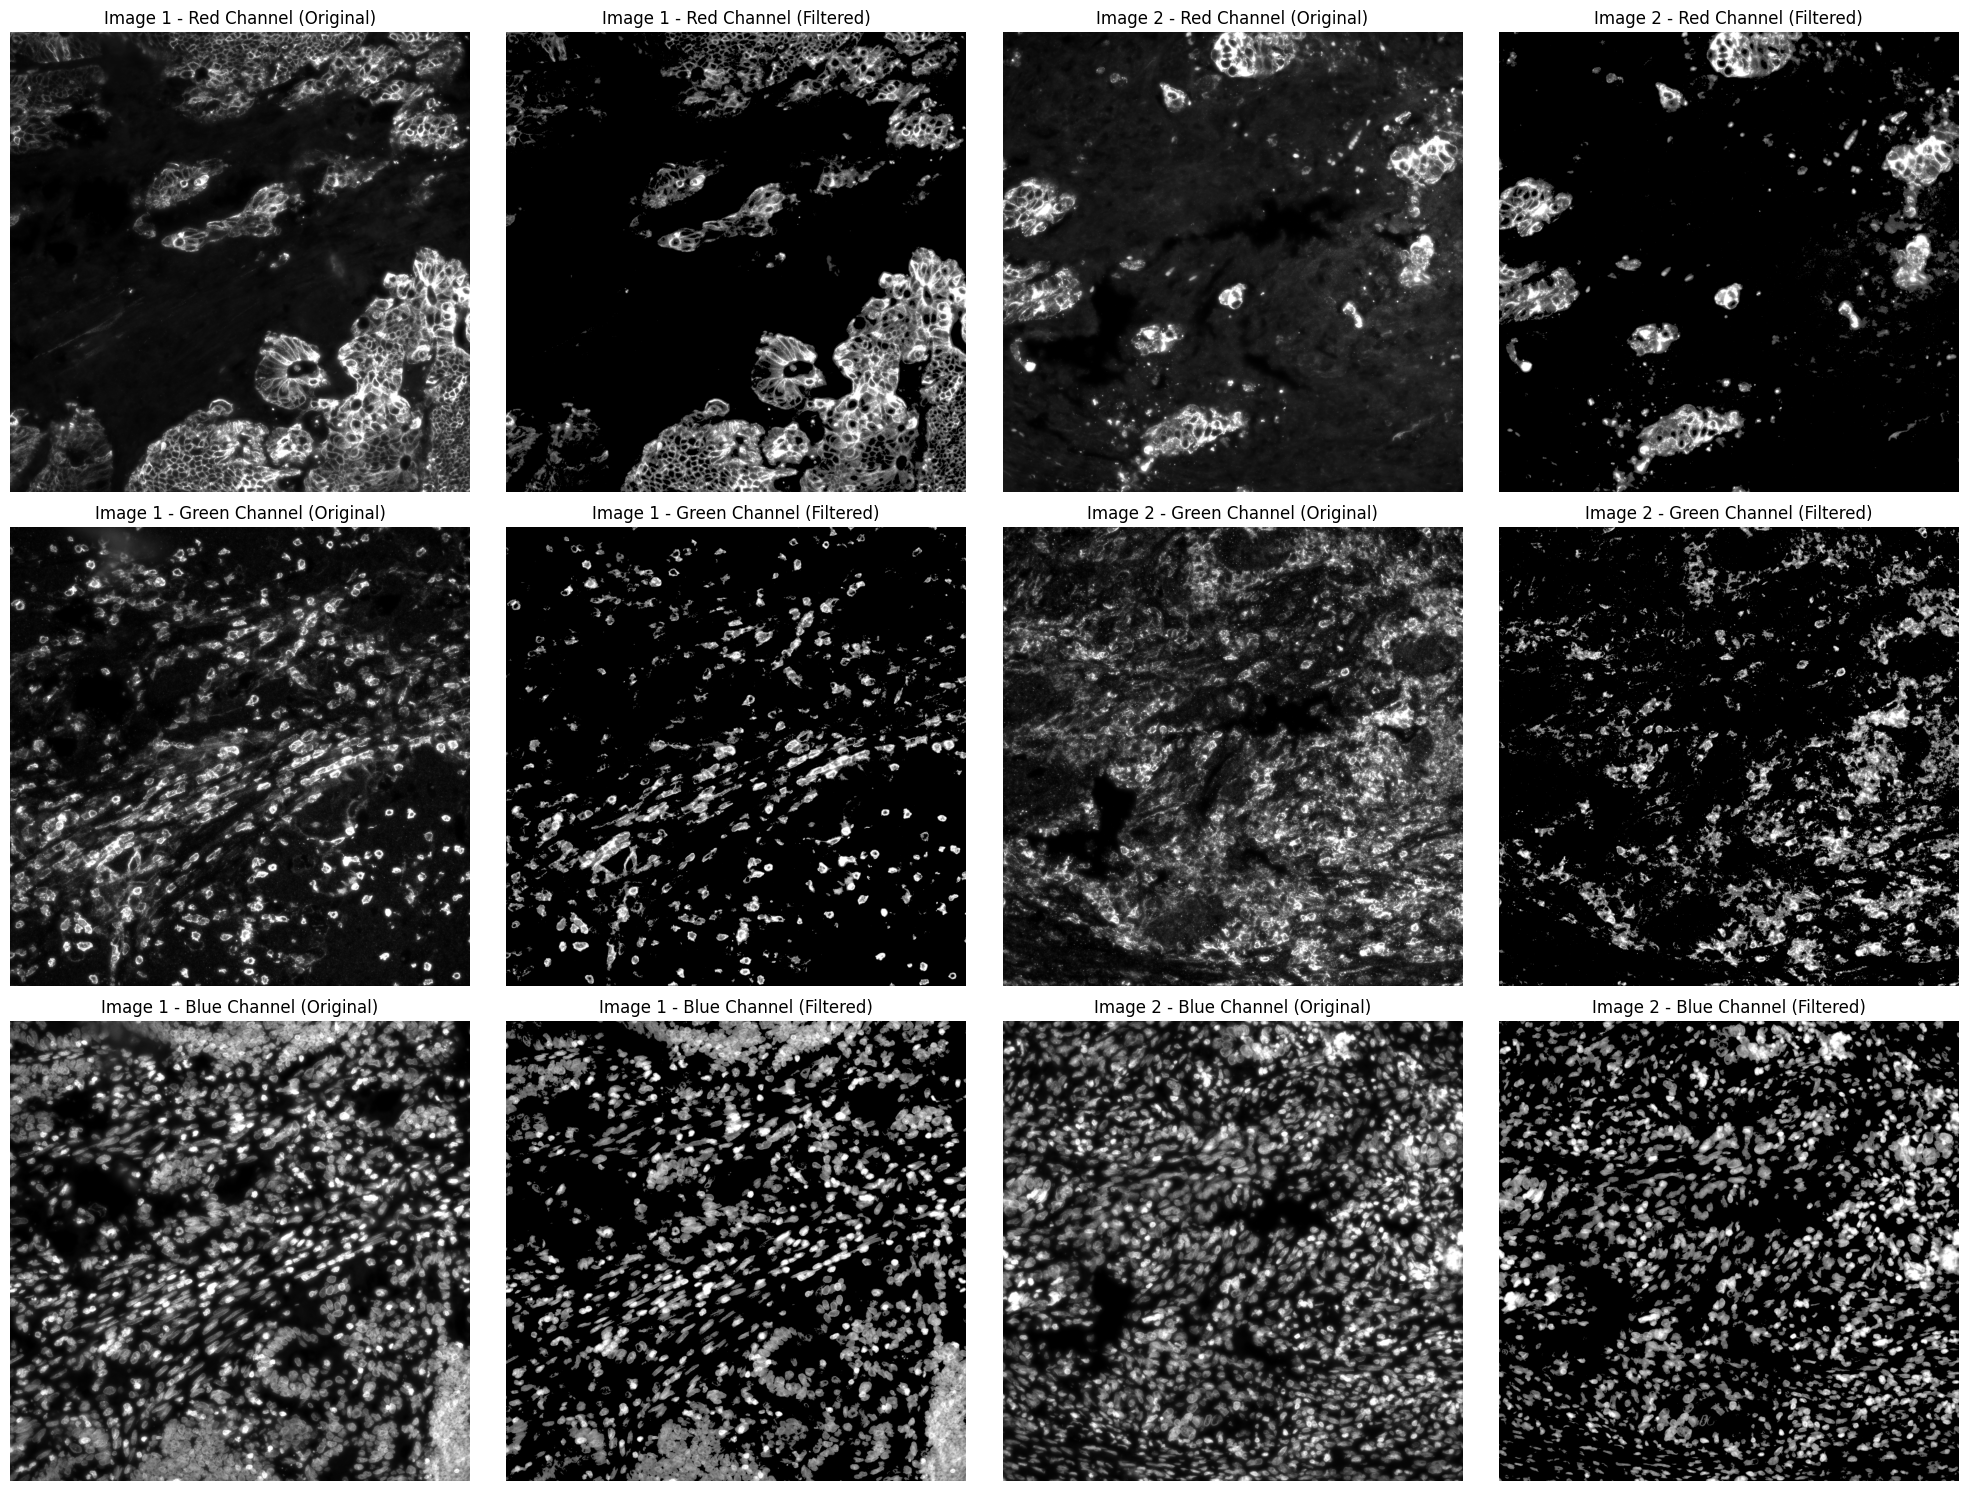

Displaying images at indices: 17 and 15


In [34]:

def preprocess_image(img, thresholds, percentiles):
    img = img.squeeze()
    filtered_img = np.empty(img.shape)
    
    for ch in range(img.shape[2]):
        img_ch = img[:, :, ch]
        # Thresholding
        th = thresholds[ch]
        if th is not None:
            img_ch = np.where(img_ch >= th, img_ch, 0)

        # Percentile filtering
        perc = percentiles[ch]
        if perc is not None:
            img_ch = img_ch[..., np.newaxis]
            img_ch = IPrep.percentile_filter(img_ch, window_size=3, percentile=perc, transf_bool=True)
            img_ch = img_ch.squeeze()

        filtered_img[:, :, ch] = img_ch
    return filtered_img



path_to_IF = "/home/martinha/PycharmProjects/phd/spatial_transcriptomics/GRIDGEN/case_studies/composites"

folder_path = path_to_IF
path_for_results =  "/home/martinha/PycharmProjects/phd/spatial_transcriptomics/GRIDGEN/case_studies/PENGUINcomposites"
# normalization outliers
up_limit = 99
down_limit = 1
binary_masks = False

# Load files
files = glob(os.path.join(folder_path, '*.tiff'))
num_images = len(files)
print(f"Number of images identified: {num_images}")

num_channels = 3
# Calculate thresholds and percentiles
thresholds = [0.2, 0.3, 0.3]
percentiles = [50, 10, 25]

images_original = list(map(IP.parse_image_pages, files))

# Preprocessing
imgs_out = map(lambda p: IPrep.remove_outliers(p, up_limit, down_limit), images_original)
imgs_norm = map(IPrep.normalize_channel_cv2_minmax, imgs_out)
filtered_images = map(lambda i: preprocess_image(i, thresholds, percentiles), imgs_norm)
imgs_filtered = list(filtered_images)

# Apply binary masks if needed
# imgs_filtered = [np.where(a > 0, 1, 0) for a in imgs_filtered]

# Select 2 random images
np.random.seed(42)  # for reproducibility
# np.random.seed(34)  # for reproducibility

random_indices = np.random.choice(len(images_original), size=2, replace=False)

# Get the images
img1_original = images_original[random_indices[0]]
img1_filtered = imgs_filtered[random_indices[0]]

img2_original = images_original[random_indices[1]]
img2_filtered = imgs_filtered[random_indices[1]]

# Create the plot: 3 rows (one per channel) x 4 columns (img1 pre, img1 post, img2 pre, img2 post)
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

channel_names = ['Red Channel', 'Green Channel', 'Blue Channel']

for ch in range(3):  # For each channel
    # Image 1 - Before
    axes[ch, 0].imshow(img1_original[:, :, ch], cmap='gray')
    axes[ch, 0].set_title(f'Image 1 - {channel_names[ch]} (Original)')
    axes[ch, 0].axis('off')
    
    # Image 1 - After
    axes[ch, 1].imshow(img1_filtered[:, :, ch], cmap='gray')
    axes[ch, 1].set_title(f'Image 1 - {channel_names[ch]} (Filtered)')
    axes[ch, 1].axis('off')
    
    # Image 2 - Before
    axes[ch, 2].imshow(img2_original[:, :, ch], cmap='gray')
    axes[ch, 2].set_title(f'Image 2 - {channel_names[ch]} (Original)')
    axes[ch, 2].axis('off')
    
    # Image 2 - After
    axes[ch, 3].imshow(img2_filtered[:, :, ch], cmap='gray')
    axes[ch, 3].set_title(f'Image 2 - {channel_names[ch]} (Filtered)')
    axes[ch, 3].axis('off')

plt.tight_layout()
plt.show()

print(f"Displaying images at indices: {random_indices[0]} and {random_indices[1]}")

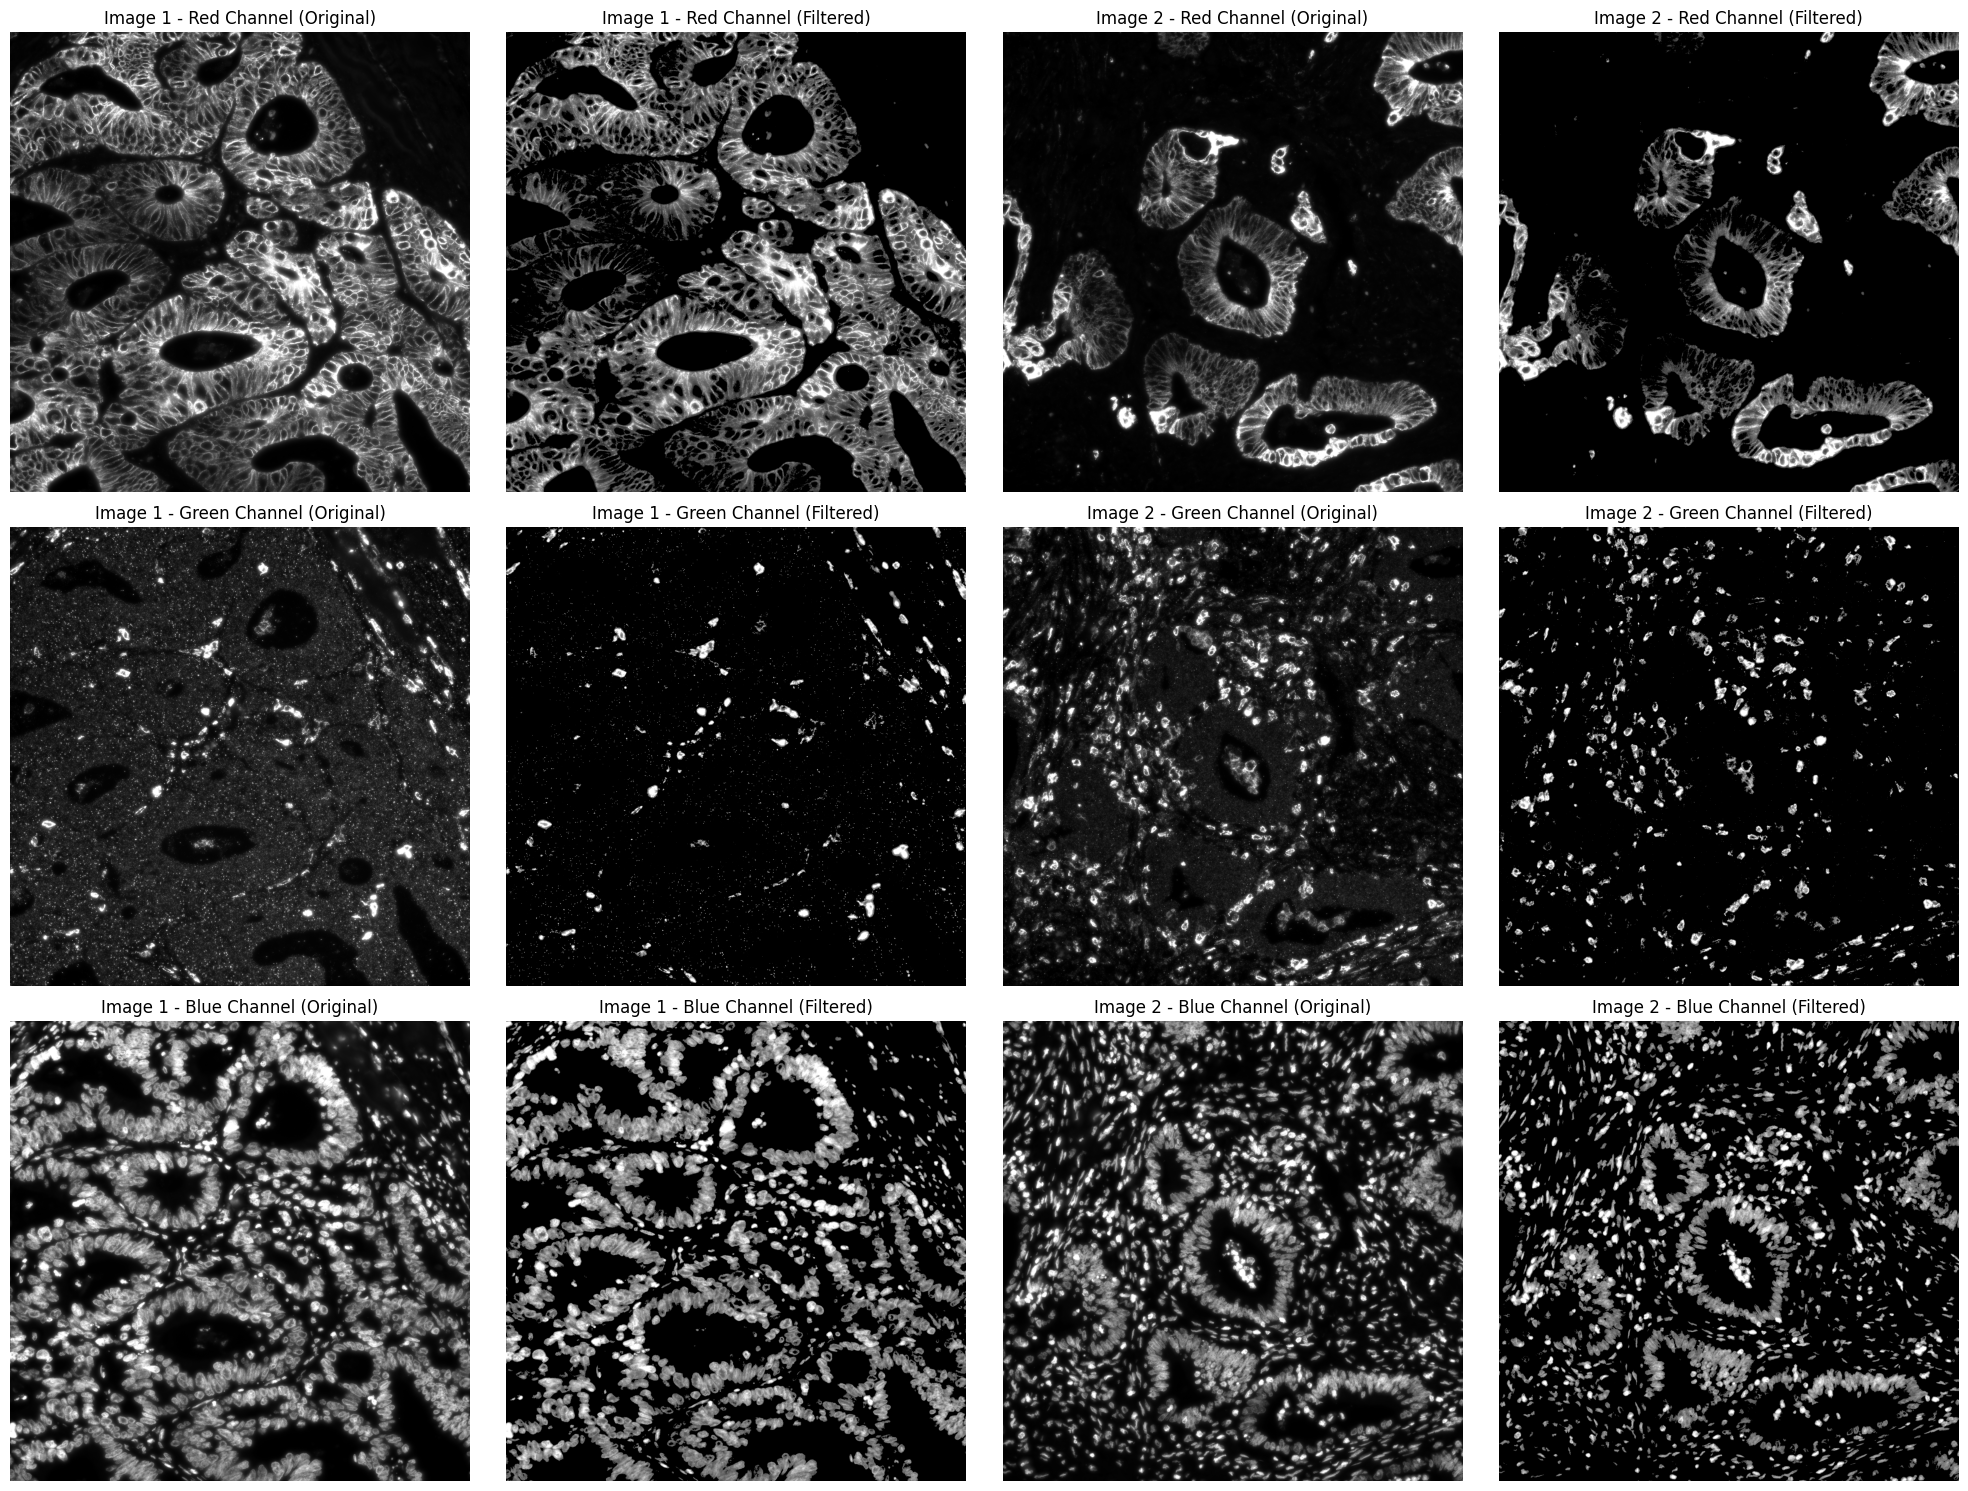

Displaying images at indices: 8 and 16


In [35]:

# Select 2 random images
np.random.seed(42)  # for reproducibility
# np.random.seed(34)  # for reproducibility

random_indices = np.random.choice(len(images_original), size=2, replace=False)

# Get the images
img1_original = images_original[random_indices[0]]
img1_filtered = imgs_filtered[random_indices[0]]

img2_original = images_original[random_indices[1]]
img2_filtered = imgs_filtered[random_indices[1]]

# Create the plot: 3 rows (one per channel) x 4 columns (img1 pre, img1 post, img2 pre, img2 post)
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

channel_names = ['Red Channel', 'Green Channel', 'Blue Channel']

for ch in range(3):  # For each channel
    # Image 1 - Before
    axes[ch, 0].imshow(img1_original[:, :, ch], cmap='gray')
    axes[ch, 0].set_title(f'Image 1 - {channel_names[ch]} (Original)')
    axes[ch, 0].axis('off')
    
    # Image 1 - After
    axes[ch, 1].imshow(img1_filtered[:, :, ch], cmap='gray')
    axes[ch, 1].set_title(f'Image 1 - {channel_names[ch]} (Filtered)')
    axes[ch, 1].axis('off')
    
    # Image 2 - Before
    axes[ch, 2].imshow(img2_original[:, :, ch], cmap='gray')
    axes[ch, 2].set_title(f'Image 2 - {channel_names[ch]} (Original)')
    axes[ch, 2].axis('off')
    
    # Image 2 - After
    axes[ch, 3].imshow(img2_filtered[:, :, ch], cmap='gray')
    axes[ch, 3].set_title(f'Image 2 - {channel_names[ch]} (Filtered)')
    axes[ch, 3].axis('off')

plt.tight_layout()
plt.show()

print(f"Displaying images at indices: {random_indices[0]} and {random_indices[1]}")

save preprocessed figures 

In [45]:
# Save images
names_save = [os.path.join(path_for_results, os.path.basename(sub)) for sub in files]
os.makedirs(path_for_results, exist_ok=True)

for img, name in zip(imgs_filtered, names_save):
    IPrep.save_images(img, name, ch_last=True)

print(f'Images saved at {path_for_results}')

Images saved at /home/martinha/PycharmProjects/phd/spatial_transcriptomics/GRIDGEN/case_studies/PENGUINcomposites
